In [128]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import polars as pl

QF_DISPLAY = {
    "body": "Original Query",
    "synonyms": "+ Gene Synonyms",
    "long": "+ Gene Synonyms & Products",
}

RERANK_DISPLAY = {
    "body": "Rerank (Original Query)",
    "synonyms": "Rerank (+ Gene Synonyms)",
    "long": "Rerank (+ Gene Synonyms & Products)",
    "hybrid": "Retrieval Fusion (long)",
}

In [129]:
# Path setup + workflow-root resolver shared by the rerank cells below.
root = Path(os.environ.get("DICTYCITE_ROOT", "../"))


def _resolve_rerank_sweep_root(cfg: dict) -> Path:
    """Directory that contains rerank_body/ (and bm25/, …). Handles outer workflow dir + nested sweep."""
    rd = cfg["rerank_dir"]
    candidates: list[Path] = []
    if rd.is_absolute():
        candidates = [rd, rd / "fixed_long_rerank_sweep"]
    else:
        for base in (root, Path("../")):
            candidates.append(base / rd)
    for c in candidates:
        if (c / "rerank_body").is_dir():
            return c
    return candidates[0] if candidates else rd

### Rerank MRR@K under each QE variant — paper supp Fig S4 source

*Research artifact + paper supp source.* Loads each `RERANK_PANEL_CONFIGS`
entry (tag × reranker sweep) and builds **one** supplementary-style figure:
**1×3 panels** (BGE-reranker-v2-m3 | MedCPT | BGE Gemma), each titled by
reranker, same MRR@K curves per panel (QE variants + optional fusion). Used
as Fig S4 (QE reranker panels). Saves
`figures/fig_s4_qe_reranker_mrr_panels.png` (under the `7d` BGE-v2-m3 sweep
`figures/` when that panel is present, otherwise the first loaded sweep).

MRR@K (7d_medcpt, from run TSVs):



method,MRR@1,MRR@5,MRR@10,MRR@20,MRR@50,MRR@100
str,f64,f64,f64,f64,f64,f64
"""Rerank (+ Gene Synonyms)""",0.5897,0.6722,0.6817,0.6845,0.6858,0.686
"""Rerank (+ Gene Synonyms & Prod…",0.5648,0.6651,0.6734,0.6765,0.6774,0.6778
"""Rerank (Original Query)""",0.5204,0.6136,0.6239,0.6275,0.6291,0.6292
"""Retrieval Fusion (long)""",0.508,0.6076,0.6185,0.6225,0.6232,0.6235


MRR@K (7d_gemma, from run TSVs):



method,MRR@1,MRR@5,MRR@10,MRR@20,MRR@50,MRR@100
str,f64,f64,f64,f64,f64,f64
"""Rerank (+ Gene Synonyms)""",0.6306,0.6957,0.7027,0.7051,0.7062,0.7065
"""Rerank (+ Gene Synonyms & Prod…",0.6234,0.695,0.7011,0.7039,0.7051,0.7054
"""Rerank (Original Query)""",0.6128,0.6883,0.6938,0.6965,0.698,0.6983
"""Retrieval Fusion (long)""",0.508,0.6076,0.6185,0.6225,0.6232,0.6235


MRR@K (7d, from run TSVs):



method,MRR@1,MRR@5,MRR@10,MRR@20,MRR@50,MRR@100
str,f64,f64,f64,f64,f64,f64
"""Rerank (+ Gene Synonyms)""",0.5382,0.6137,0.6229,0.6256,0.6278,0.6282
"""Rerank (+ Gene Synonyms & Prod…",0.5275,0.6132,0.6224,0.6242,0.6261,0.6267
"""Retrieval Fusion (long)""",0.508,0.6076,0.6185,0.6225,0.6232,0.6235
"""Rerank (Original Query)""",0.4813,0.5687,0.5761,0.5795,0.5814,0.5819


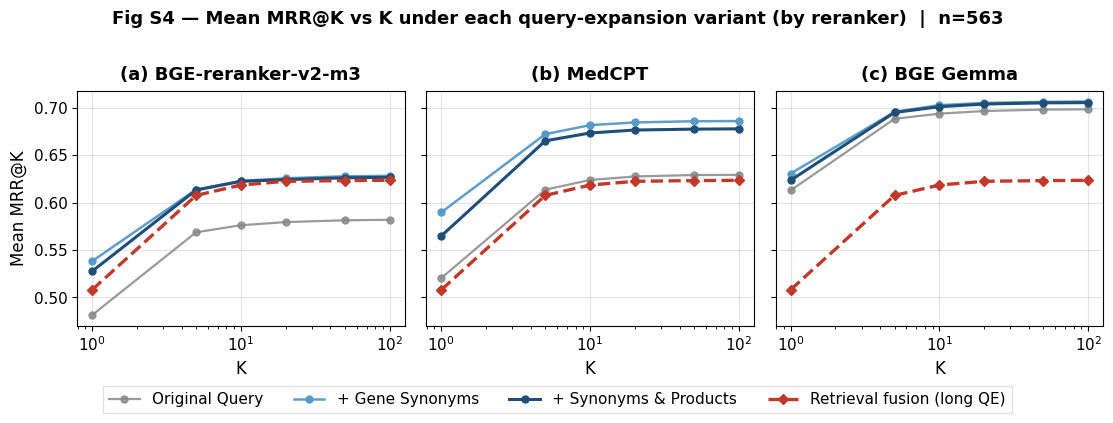

Saved Fig S4 (1×3 reranker panels): ../output/workflow_baseline_full_sweep/workflow_fixed_long_rerank_sweep_7d/fixed_long_rerank_sweep/figures/fig_s4_qe_reranker_mrr_panels.png


In [140]:
# CE rerank MRR@K only — run TSVs; no combined_sweep_metrics / retrieval sweep.

RERANK_PANEL_CONFIGS = [
    {
        "tag": "7d_medcpt",
        "rerank_dir": Path("output/workflow_baseline_full_sweep/workflow_fixed_long_rerank_sweep_7d_medcpt/fixed_long_rerank_sweep"),
        "gold_jsonl": Path("output/dicty_gold_build/7d_dicty_gold_query_expansion_benchmark.jsonl"),
        "run_token": "7d_dicty_gold_query_expansion_benchmark",
    },
    {
        "tag": "7d_gemma",
        "rerank_dir": Path("output/workflow_baseline_full_sweep/workflow_fixed_long_rerank_sweep_7d_gemma/fixed_long_rerank_sweep"),
        "gold_jsonl": Path("output/dicty_gold_build/7d_dicty_gold_query_expansion_benchmark.jsonl"),
        "run_token": "7d_dicty_gold_query_expansion_benchmark",
    },
    {
        "tag": "7d",
        "rerank_dir": Path("output/workflow_baseline_full_sweep/workflow_fixed_long_rerank_sweep_7d/fixed_long_rerank_sweep"),
        "gold_jsonl": Path("output/dicty_gold_build/7d_dicty_gold_query_expansion_benchmark.jsonl"),
        "run_token": "7d_dicty_gold_query_expansion_benchmark",
    },
]

# Same K grid as Fig 4 panel (c) (`fig2_ks_mrr`).
KS_MAP_RR = [1, 5, 10, 20, 50, 100]

# Match Fig 4 `QE_STYLE` (panel c): blue intensity + grey baseline.
QE_STYLE_S4 = {
    "body":     {"color": "#888888", "label": "Original Query",        "lw": 1.6, "ls": "-",  "alpha": 0.85},
    "synonyms": {"color": "#5499c7", "label": "+ Gene Synonyms",       "lw": 1.8, "ls": "-",  "alpha": 0.95},
    "long":     {"color": "#1f4e79", "label": "+ Synonyms & Products", "lw": 2.2, "ls": "-",  "alpha": 1.00},
}
# Panel (c) omits fusion; use a hue outside the QE blue/grey ramp plus dashed style.
FUSION_S4 = {
    "color": "#c0392b",
    "label": "Retrieval fusion (long QE)",
    "lw": 2.4,
    "ls": "--",
    "alpha": 1.0,
}


def _rp_load_gold(path: Path) -> dict[str, list[str]]:
    gold: dict[str, list[str]] = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            if not qid:
                continue
            pmids: list[str] = []
            for doc in q.get("documents", []) or []:
                if isinstance(doc, str) and doc.startswith("http"):
                    pmids.append(doc.split("/")[-1])
                elif doc:
                    pmids.append(str(doc))
            for d in q.get("docs", []) or []:
                if isinstance(d, dict) and d.get("pmid"):
                    pmids.append(str(d["pmid"]))
            gold[qid] = list(set(pmids))
    return gold


def _rp_load_run(path: Path) -> dict[str, list[str]]:
    run: dict[str, list[str]] = {}
    header = None

    def _header_indices(h: list[str]) -> tuple[int, int]:
        low = [p.lstrip("\ufeff").lower() for p in h]
        qid_idx = low.index("qid") if "qid" in low else 0
        for key in ("docno", "docid", "doc"):
            if key in low:
                return qid_idx, low.index(key)
        return qid_idx, 1

    with path.open(encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if not parts:
                continue
            if parts[0].lstrip("\ufeff").lower() == "qid":
                header = parts
                continue
            if len(parts) < 3:
                continue
            if header is not None:
                qid_idx, docno_idx = _header_indices(header)
            else:
                qid_idx, docno_idx = 0, 1
            qid, docno = parts[qid_idx], parts[docno_idx]
            run.setdefault(qid, []).append(docno)
    return run


def _rp_mrr_at_k(ranked: list[str], relset: set[str], k: int) -> float:
    for i, docno in enumerate(ranked[:k], start=1):
        if docno in relset:
            return 1.0 / i
    return 0.0


def _rp_mean_mrr_at_k(gold: dict[str, list[str]], run: dict[str, list[str]], k: int) -> float:
    scores = []
    for qid, relset in gold.items():
        ranked = run.get(qid, [])
        scores.append(_rp_mrr_at_k(ranked, set(relset), k))
    return sum(scores) / len(scores) if scores else 0.0


_rc_rr = {
    "figure.figsize": (6.5, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
}

_TAG_TO_RERANKER_TITLE = {
    "7d": "BGE-reranker-v2-m3",
    "7d_medcpt": "MedCPT",
    "7d_gemma": "BGE Gemma",
    "7e": "BGE-reranker-v2-m3",
    "7e_medcpt": "MedCPT",
    "7e_gemma": "BGE Gemma",
}

# Fig S4 column order (left → right): v2-m3 first for comparison with Fig 4 panel (c).
_S4_PANEL_TAG_ORDER = ["7d", "7d_medcpt", "7d_gemma", "7e", "7e_medcpt", "7e_gemma"]
_s4_tag_sort_key = {t: i for i, t in enumerate(_S4_PANEL_TAG_ORDER)}

s4_panel_specs: list[dict] = []

for cfg in RERANK_PANEL_CONFIGS:
    rerank_root = _resolve_rerank_sweep_root(cfg)
    if not (rerank_root / "rerank_body").is_dir():
        print(f"[{cfg['tag']}] Skip rerank panel: no rerank_body under {rerank_root}")
        continue

    gold_path = cfg["gold_jsonl"]
    gold_resolved = gold_path if gold_path.is_absolute() else None
    if gold_resolved is None:
        for base in (root, Path("../")):
            p = base / gold_path
            if p.is_file():
                gold_resolved = p
                break
        if gold_resolved is None:
            gold_resolved = root / gold_path
    if not gold_resolved.is_file():
        print(f"[{cfg['tag']}] Skip: gold JSONL not found: {gold_resolved}")
        continue

    rerank_dirs = {
        "body": rerank_root / "rerank_body",
        "synonyms": rerank_root / "rerank_synonyms",
        "long": rerank_root / "rerank_long",
        "hybrid": rerank_root / "retrieval" / "fusion",
    }

    gold_bench = _rp_load_gold(gold_resolved)
    run_token = cfg["run_token"]
    mrr_curves: dict[str, list[float]] = {}

    for method_key, rdir in rerank_dirs.items():
        runs_dir = rdir / "runs"
        if not runs_dir.is_dir():
            continue
        matching = sorted(f for f in runs_dir.glob("*.tsv") if run_token in f.stem)
        if not matching:
            continue
        if len(matching) > 1:
            print(
                f"[{cfg['tag']}] Warning: {len(matching)} TSVs match '{run_token}' in {runs_dir}; "
                f"using {matching[0].name}"
            )
        run_data = _rp_load_run(matching[0])
        label = RERANK_DISPLAY[method_key]
        mrr_curves[label] = [_rp_mean_mrr_at_k(gold_bench, run_data, k) for k in KS_MAP_RR]

    if not mrr_curves:
        print(f"[{cfg['tag']}] No run TSVs matched '{run_token}' — nothing to plot.")
        continue

    rows = []
    for method, vals in mrr_curves.items():
        row = {"method": method}
        for k, v in zip(KS_MAP_RR, vals):
            row[f"MRR@{k}"] = round(v, 4)
        rows.append(row)
    df_rr = pd.DataFrame(rows).sort_values("MRR@10", ascending=False).reset_index(drop=True)
    print(f"MRR@K ({cfg['tag']}, from run TSVs):\n")
    display(pl.from_pandas(df_rr))

    figures_dir = rerank_root / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    include_hybrid = RERANK_DISPLAY["hybrid"] in mrr_curves
    s4_panel_specs.append(
        {
            "tag": cfg["tag"],
            "figures_dir": figures_dir,
            "mrr_curves": mrr_curves,
            "include_hybrid": include_hybrid,
            "n_queries": len(gold_bench),
            "reranker_title": _TAG_TO_RERANKER_TITLE.get(cfg["tag"], "Reranker"),
        }
    )

s4_panel_specs.sort(key=lambda p: _s4_tag_sort_key.get(p["tag"], 99))

# Fig S4: one row × one column per reranker (QE curves + optional fusion).
if s4_panel_specs:
    n_p = len(s4_panel_specs)
    any_hybrid = any(p["include_hybrid"] for p in s4_panel_specs)
    n_q = s4_panel_specs[0]["n_queries"]

    out_dir = next(
        (p["figures_dir"] for p in s4_panel_specs if p["tag"] == "7d"),
        s4_panel_specs[0]["figures_dir"],
    )
    out_path = out_dir / "fig_s4_qe_reranker_mrr_panels.png"

    with plt.rc_context(_rc_rr):
        # Narrower columns, slightly taller than wide per axis for a compact “almost square” look.
        _s4_col_w, _s4_row_h = 3.75, 3.95
        fig, axes = plt.subplots(1, n_p, figsize=(_s4_col_w * n_p, _s4_row_h), sharey=True)
        if n_p == 1:
            axes_list = [axes]
        else:
            axes_list = list(axes)

        panel_letters = "abcdefghij"
        for i, (ax, spec) in enumerate(zip(axes_list, s4_panel_specs)):
            curves = spec["mrr_curves"]
            for qf in ["body", "synonyms", "long"]:
                method_label = RERANK_DISPLAY[qf]
                if method_label not in curves:
                    continue
                s = QE_STYLE_S4[qf]
                ax.plot(
                    KS_MAP_RR,
                    curves[method_label],
                    marker="o",
                    markersize=5,
                    color=s["color"],
                    linewidth=s["lw"],
                    linestyle=s["ls"],
                    alpha=s["alpha"],
                )
            hybrid_label = RERANK_DISPLAY["hybrid"]
            if hybrid_label in curves:
                fs = FUSION_S4
                ax.plot(
                    KS_MAP_RR,
                    curves[hybrid_label],
                    marker="D",
                    markersize=5,
                    color=fs["color"],
                    linewidth=fs["lw"],
                    linestyle=fs["ls"],
                    alpha=fs["alpha"],
                )
            ax.set_title(
                f"({panel_letters[i]}) {spec['reranker_title']}",
                fontsize=13,
                fontweight="bold",
                pad=8,
            )
            ax.set_xlabel("K")
            ax.set_xscale("log")
            if i == 0:
                ax.set_ylabel("Mean MRR@K")
            ax.grid(True, axis="y", alpha=0.35)
            ax.grid(True, axis="x", alpha=0.35)

        leg_handles = []
        for qf in ["body", "synonyms", "long"]:
            s = QE_STYLE_S4[qf]
            leg_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=s["color"],
                    marker="o",
                    linestyle=s["ls"],
                    linewidth=s["lw"],
                    markersize=5,
                    alpha=s["alpha"],
                    label=s["label"],
                )
            )
        if any_hybrid:
            fs = FUSION_S4
            leg_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=fs["color"],
                    marker="D",
                    linestyle=fs["ls"],
                    linewidth=fs["lw"],
                    markersize=5,
                    alpha=fs["alpha"],
                    label=fs["label"],
                )
            )
        fig.legend(
            handles=leg_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=4 if any_hybrid else 3,
            fontsize=11,
            frameon=True,
            fancybox=False,
            edgecolor="0.85",
        )
        fig.suptitle(
            f"Fig S4 — Mean MRR@K vs K under each query-expansion variant (by reranker)  |  n={n_q}",
            fontsize=13,
            fontweight="bold",
            y=1.02,
        )
        plt.tight_layout()
        fig.subplots_adjust(bottom=0.22)
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)

    print(f"Saved Fig S4 (1×{n_p} reranker panels): {out_path}")
else:
    print("Fig S4: no rerank panel data collected — check rerank dirs and run TSVs.")

Rerank MRR@K from run TSVs: see the **Rerank MRR@K under each QE variant** cell above (BGE-reranker-v2-m3 / MedCPT / BGE Gemma). In the diagnostic **per-batch query-field sweep** loop near the top, rerank appears as the third panel when TSVs exist under each benchmark's `rerank_dir`.

# Fig 4 Candidate — Main Paper (QE main result)

*Paper role:* main-paper figure for the query-expansion contribution.
Showcases QE on the standard pipeline (BGE-reranker-v2-m3): retrieval recall
improves substantially with QE, that gain carries through the rerank stage,
and the inset (panel d) shows the QE lift shrinks as the reranker gets
stronger — orthogonality with diminishing returns.

- Panel (a): BM25 Recall@K, 3 QE variants — body / synonyms / long
- Panel (b): Dense Recall@K, same 3 QE variants
- Panel (c): BGE-reranker-v2-m3 MRR@K under each QE variant
- Panel (d): QE Δ MRR@10 (synonyms − body) across {BGE-v2-m3, MedCPT, BGE Gemma}

Full per-reranker MRR@K curves (paper supp Fig S4) are produced by the
*"Rerank MRR@K under each QE variant"* cell above as
`figures/fig_s4_qe_reranker_mrr_panels.png` (1×3 reranker panels).

Sample size: n=563 (7d expanded-query benchmark). The ranker-comparison
Fig 3 uses n=1,656 (default-query full goldset) — the caption must flag the
difference.

In [131]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


_root = Path.cwd().resolve()
if not (_root / "output").exists() and (_root.parent / "output").exists():
    _root = _root.parent

FIG2_TAG = "7d_dicty_gold_query_expansion_benchmark"
fig2_qe_sweep_dir   = _root / "output" / "workflow_baseline_full_sweep" / "workflow_query_field_sweep_no_rm3_7d" / "query_field_sweep"
fig2_rerank_dir     = _root / "output" / "workflow_baseline_full_sweep" / "workflow_fixed_long_rerank_sweep_7d" / "fixed_long_rerank_sweep"
fig2_gold_jsonl     = _root / "output" / "dicty_gold_build" / "7d_dicty_gold_query_expansion_benchmark.jsonl"
fig2_out_dir        = fig2_qe_sweep_dir / "figures"
fig2_out_dir.mkdir(parents=True, exist_ok=True)


# Self-contained loaders (independent of the per-tag loop above).
def _fig2_load_gold(path: Path) -> dict[str, set[str]]:
    gold: dict[str, set[str]] = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            pmids: list[str] = []
            for doc in q.get("documents", []) or []:
                if isinstance(doc, str) and doc.startswith("http"):
                    pmids.append(doc.rsplit("/", 1)[-1])
                elif doc:
                    pmids.append(str(doc))
            for d in q.get("docs", []) or []:
                if isinstance(d, dict) and d.get("pmid"):
                    pmids.append(str(d["pmid"]))
            if qid and pmids:
                gold[qid] = set(pmids)
    return gold


def _fig2_load_run(path: Path) -> dict[str, list[str]]:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lstrip("﻿").lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}: {df.columns.tolist()}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return {str(q): g[doc_col].tolist() for q, g in df.groupby(qid_col, sort=False)}


def _fig2_mrr_at_k(docs: list[str], rels: set[str], k: int) -> float:
    for i, d in enumerate(docs[:k], 1):
        if d in rels:
            return 1.0 / i
    return 0.0


def _fig2_mean_mrr(run: dict[str, list[str]], gold: dict[str, set[str]], k: int) -> float:
    vals = [_fig2_mrr_at_k(run.get(q, []), rels, k) for q, rels in gold.items()]
    return float(np.mean(vals)) if vals else 0.0


fig2_gold = _fig2_load_gold(fig2_gold_jsonl)
print(f"Fig 2 gold: n={len(fig2_gold)} queries")

Fig 2 gold: n=563 queries


In [132]:
# Recall@K from QE sweep CSV (panels a, b)
sweep_df = pd.read_csv(fig2_qe_sweep_dir / "combined_sweep_metrics.csv")
sweep_df = sweep_df[sweep_df["batch"] == FIG2_TAG]

recall_cols_all = sorted(
    [c for c in sweep_df.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
fig2_ks_recall = [int(c.split("@")[1]) for c in recall_cols_all if int(c.split("@")[1]) <= 1000]
fig2_recall_cols = [f"MeanR@{k}" for k in fig2_ks_recall]


def _recall_for_qf(stage: str, qf_col: str) -> dict[str, list[float]]:
    out = {}
    for qf in ["body", "synonyms", "long"]:
        rows = sweep_df[(sweep_df["stage"] == stage) & (sweep_df[qf_col] == qf)]
        if rows.empty:
            continue
        # Pick first row (per qf, retrieval Recall@K is the same regardless of fusion params)
        out[qf] = [float(rows.iloc[0][c]) for c in fig2_recall_cols]
    return out


bm25_recall  = _recall_for_qf("bm25",  "bm25_query_field")
dense_recall = _recall_for_qf("dense", "dense_query_field")
print("BM25 Recall@100 by QE:", {qf: round(v[fig2_ks_recall.index(100)], 4) for qf, v in bm25_recall.items()})
print("Dense Recall@100 by QE:", {qf: round(v[fig2_ks_recall.index(100)], 4) for qf, v in dense_recall.items()})

BM25 Recall@100 by QE: {'body': 0.8163, 'synonyms': 0.8616, 'long': 0.9013}
Dense Recall@100 by QE: {'body': 0.7621, 'synonyms': 0.8524, 'long': 0.881}


In [133]:
# MRR@K from rerank run TSVs (panel c)
fig2_ks_mrr = [1, 5, 10, 20, 50, 100]

rerank_runs: dict[str, dict[str, list[str]]] = {}
for qf in ["body", "synonyms", "long"]:
    runs_dir = fig2_rerank_dir / f"rerank_{qf}" / "runs"
    candidates = list(runs_dir.glob(f"*{FIG2_TAG}*.tsv"))
    if candidates:
        rerank_runs[qf] = _fig2_load_run(candidates[0])

# Retrieval fusion (long QE) — punchline line, no rerank
fusion_long_dir = fig2_rerank_dir / "retrieval" / "fusion" / "runs"
fusion_long_candidates = list(fusion_long_dir.glob(f"*{FIG2_TAG}*.tsv"))
fusion_long_run = _fig2_load_run(fusion_long_candidates[0]) if fusion_long_candidates else {}

mrr_curves: dict[str, list[float]] = {}
for qf, run in rerank_runs.items():
    mrr_curves[qf] = [_fig2_mean_mrr(run, fig2_gold, k) for k in fig2_ks_mrr]
if fusion_long_run:
    mrr_curves["fusion_long"] = [_fig2_mean_mrr(fusion_long_run, fig2_gold, k) for k in fig2_ks_mrr]

print("MRR@10 by panel-c method:", {m: round(v[fig2_ks_mrr.index(10)], 4) for m, v in mrr_curves.items()})

MRR@10 by panel-c method: {'body': 0.5761, 'synonyms': 0.6229, 'long': 0.6224, 'fusion_long': 0.6185}


In [134]:
# Cross-reranker MRR@10 across QE variants — feeds panel (d) inset.
# We load (reranker × QE) run TSVs and compute MRR@10 for each combo so the
# inset can display QE Δ MRR@10 per reranker.
RERANKER_DIRS_INSET: dict[str, Path] = {
    "BGE-reranker-v2-m3": _root / "output" / "workflow_baseline_full_sweep" / "workflow_fixed_long_rerank_sweep_7d" / "fixed_long_rerank_sweep",
    "MedCPT":             _root / "output" / "workflow_baseline_full_sweep" / "workflow_fixed_long_rerank_sweep_7d_medcpt" / "fixed_long_rerank_sweep",
    "BGE Gemma":          _root / "output" / "workflow_baseline_full_sweep" / "workflow_fixed_long_rerank_sweep_7d_gemma" / "fixed_long_rerank_sweep",
}

cross_reranker_mrr10: dict[str, dict[str, float]] = {}
for rname, rdir in RERANKER_DIRS_INSET.items():
    cross_reranker_mrr10[rname] = {}
    for qf in ["body", "synonyms", "long"]:
        runs_dir = rdir / f"rerank_{qf}" / "runs"
        if not runs_dir.is_dir():
            continue
        candidates = list(runs_dir.glob(f"*{FIG2_TAG}*.tsv"))
        if not candidates:
            continue
        run = _fig2_load_run(candidates[0])
        cross_reranker_mrr10[rname][qf] = _fig2_mean_mrr(run, fig2_gold, 10)

print("\nQE × reranker MRR@10:")
for rname, qf_mrr in cross_reranker_mrr10.items():
    body = qf_mrr.get("body", float("nan"))
    syn  = qf_mrr.get("synonyms", float("nan"))
    long = qf_mrr.get("long", float("nan"))
    delta_long_body = (long - body) if (not np.isnan(body) and not np.isnan(long)) else float("nan")
    delta_syn_body  = (syn - body) if (not np.isnan(body) and not np.isnan(syn)) else float("nan")
    print(
        f"  {rname:22s}  body={body:.4f}  synonyms={syn:.4f}  long={long:.4f}  "
        f"Δ(long−body)={delta_long_body:+.4f}  Δ(syn−body)={delta_syn_body:+.4f}"
    )


QE × reranker MRR@10:
  BGE-reranker-v2-m3      body=0.5761  synonyms=0.6229  long=0.6224  Δ(long−body)=+0.0463  Δ(syn−body)=+0.0467
  MedCPT                  body=0.6239  synonyms=0.6817  long=0.6734  Δ(long−body)=+0.0495  Δ(syn−body)=+0.0578
  BGE Gemma               body=0.6938  synonyms=0.7027  long=0.7011  Δ(long−body)=+0.0073  Δ(syn−body)=+0.0089


Saved: /Users/yun/develop/dictycite/output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7d/query_field_sweep/figures/fig4_candidate_qe_main.png


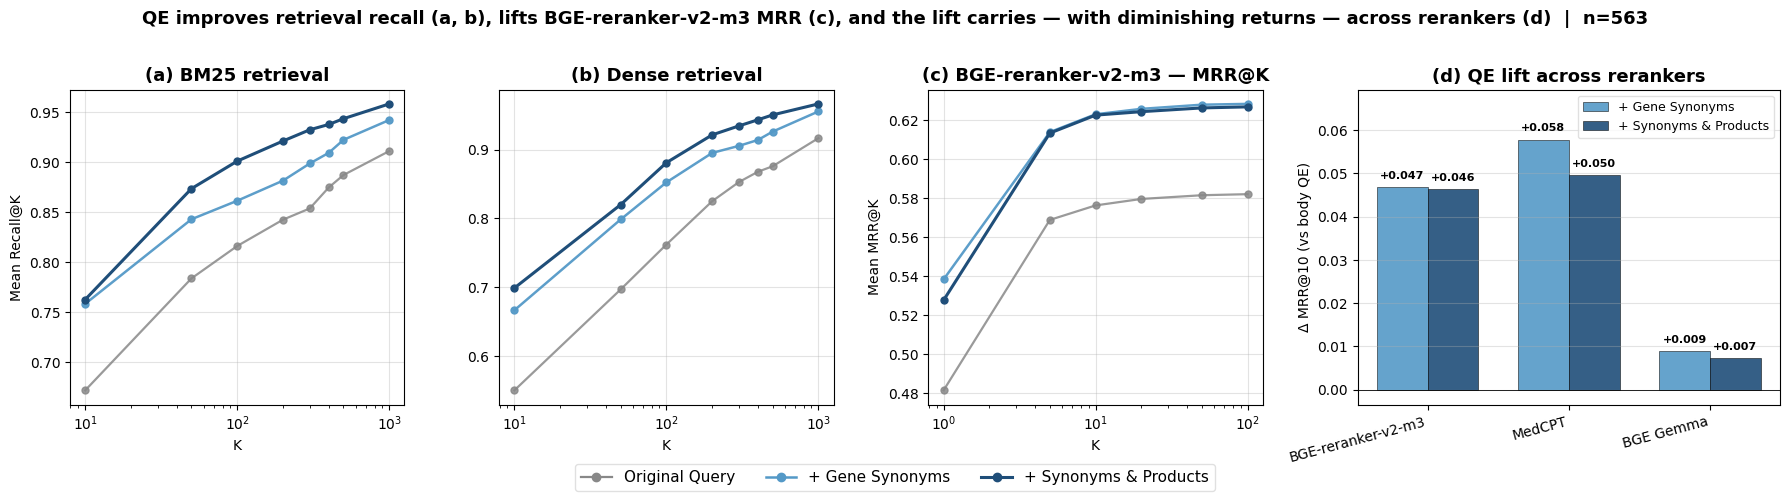

In [135]:
# Style: blue gradient for QE intensity, green for fusion punchline (matches Fig 1's "Fusion" color).
QE_STYLE = {
    "body":     {"color": "#888888", "label": "Original Query",        "lw": 1.6, "ls": "-",  "alpha": 0.85},
    "synonyms": {"color": "#5499c7", "label": "+ Gene Synonyms",       "lw": 1.8, "ls": "-",  "alpha": 0.95},
    "long":     {"color": "#1f4e79", "label": "+ Synonyms & Products", "lw": 2.2, "ls": "-",  "alpha": 1.00},
}
FUSION_STYLE = {
    "color": "#2ca02c", "label": "Retrieval Fusion (long QE) — no rerank",
    "lw": 2.6, "ls": "-", "alpha": 1.00,
}

n_q = len(fig2_gold)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.7), gridspec_kw={"width_ratios": [0.95, 0.95, 0.95, 1.20]})
ax_a, ax_b, ax_c, ax_d = axes


# Panel (a): BM25 Recall@K
for qf in ["body", "synonyms", "long"]:
    if qf not in bm25_recall:
        continue
    s = QE_STYLE[qf]
    ax_a.plot(fig2_ks_recall, bm25_recall[qf], marker="o", markersize=5,
              color=s["color"], linewidth=s["lw"], linestyle=s["ls"], alpha=s["alpha"])
ax_a.set_title("(a) BM25 retrieval", fontsize=13, fontweight="bold")
ax_a.set_xscale("log")
ax_a.set_xlabel("K")
ax_a.set_ylabel("Mean Recall@K")
ax_a.grid(True, axis="y", alpha=0.35)
ax_a.grid(True, axis="x", alpha=0.35)


# Panel (b): Dense Recall@K
for qf in ["body", "synonyms", "long"]:
    if qf not in dense_recall:
        continue
    s = QE_STYLE[qf]
    ax_b.plot(fig2_ks_recall, dense_recall[qf], marker="o", markersize=5,
              color=s["color"], linewidth=s["lw"], linestyle=s["ls"], alpha=s["alpha"])
ax_b.set_title("(b) Dense retrieval", fontsize=13, fontweight="bold")
ax_b.set_xscale("log")
ax_b.set_xlabel("K")
ax_b.set_ylabel("")
ax_b.grid(True, axis="y", alpha=0.35)
ax_b.grid(True, axis="x", alpha=0.35)


# Panel (c): BGE-reranker-v2-m3 MRR@K under each QE variant. The retrieval-fusion
# line (no rerank) was deliberately dropped to keep the panel clean; that
# comparison lives in the diagnostic cell below.
for qf in ["body", "synonyms", "long"]:
    if qf not in mrr_curves:
        continue
    s = QE_STYLE[qf]
    ax_c.plot(fig2_ks_mrr, mrr_curves[qf], marker="o", markersize=5,
              color=s["color"], linewidth=s["lw"], linestyle=s["ls"], alpha=s["alpha"])

ax_c.set_title("(c) BGE-reranker-v2-m3 — MRR@K", fontsize=13, fontweight="bold")
ax_c.set_xscale("log")
ax_c.set_xlabel("K")
ax_c.set_ylabel("Mean MRR@K")
ax_c.grid(True, axis="y", alpha=0.35)
ax_c.grid(True, axis="x", alpha=0.35)


# Panel (d): QE lift across rerankers. Two nested bars per reranker —
# Δ MRR@10 (synonyms − body) and Δ MRR@10 (long − body) — using the same
# blue gradient as panels (a)–(c) so QE intensity is visually consistent.
# The diminishing bar height across the row tells the orthogonality story:
# QE compounds with weaker rerankers; with a strong enough reranker
# (BGE Gemma) the marginal QE benefit shrinks.
inset_reranker_order = ["BGE-reranker-v2-m3", "MedCPT", "BGE Gemma"]
inset_qf_pair = ["synonyms", "long"]

inset_data: dict[str, dict[str, float]] = {}
for rname in inset_reranker_order:
    qf_mrr = cross_reranker_mrr10.get(rname, {})
    body = qf_mrr.get("body", float("nan"))
    inset_data[rname] = {}
    for qf in inset_qf_pair:
        v = qf_mrr.get(qf, float("nan"))
        inset_data[rname][qf] = (v - body) if not (np.isnan(body) or np.isnan(v)) else float("nan")

xpos = np.arange(len(inset_reranker_order))
bar_width = 0.36

all_deltas: list[float] = []
for i, qf in enumerate(inset_qf_pair):
    deltas = [inset_data[r].get(qf, float("nan")) for r in inset_reranker_order]
    deltas_plot = [0.0 if np.isnan(d) else d for d in deltas]
    all_deltas.extend(d for d in deltas if not np.isnan(d))
    offset = (i - 0.5) * bar_width
    bars = ax_d.bar(
        xpos + offset, deltas_plot, bar_width,
        color=QE_STYLE[qf]["color"], alpha=0.9, edgecolor="black", linewidth=0.4,
        label=QE_STYLE[qf]["label"],
    )
    for bar, delta in zip(bars, deltas):
        if np.isnan(delta):
            continue
        h = bar.get_height()
        ax_d.text(
            bar.get_x() + bar.get_width() / 2,
            h + (0.0015 if h >= 0 else -0.0015),
            f"{delta:+.3f}",
            ha="center", va="bottom" if h >= 0 else "top",
            fontsize=8, fontweight="bold",
        )

ax_d.axhline(0, color="black", linewidth=0.6)
ax_d.set_xticks(xpos)
ax_d.set_xticklabels(inset_reranker_order, rotation=15, ha="right", fontsize=10)
ax_d.set_ylabel("Δ MRR@10 (vs body QE)")
ax_d.set_title("(d) QE lift across rerankers", fontsize=13, fontweight="bold")
ax_d.legend(fontsize=9, loc="upper right", frameon=True, edgecolor="0.85")
ax_d.grid(True, axis="y", alpha=0.35)

if all_deltas:
    y_max = max(all_deltas)
    y_min = min(0.0, min(all_deltas))
    pad = (y_max - y_min) * 0.20 if y_max > y_min else 0.01
    ax_d.set_ylim(y_min - pad * 0.3, y_max + pad)


# Shared legend
legend_handles = []
for qf in ["body", "synonyms", "long"]:
    s = QE_STYLE[qf]
    legend_handles.append(Line2D([0], [0], color=s["color"], marker="o",
                                 linewidth=s["lw"], label=s["label"]))
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
           ncol=3, fontsize=11, frameon=True, edgecolor="0.85")

fig.suptitle(
    f"QE improves retrieval recall (a, b), lifts BGE-reranker-v2-m3 MRR (c), "
    f"and the lift carries — with diminishing returns — across rerankers (d)  |  n={n_q}",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
fig.subplots_adjust(bottom=0.18)

fig2_path = fig2_out_dir / "fig4_candidate_qe_main.png"
fig.savefig(fig2_path, dpi=150, bbox_inches="tight")
print("Saved:", fig2_path)
plt.show()

## Numbers for §3.2 caption / text

In [136]:
def _fmt(v: float) -> str:
    return f"{v:.4f}"


print(f"=== Sample size: n={n_q} ===\n")
print("Panel (a) BM25 Recall@100 by QE:")
for qf in ["body", "synonyms", "long"]:
    if qf in bm25_recall:
        v = bm25_recall[qf][fig2_ks_recall.index(100)]
        print(f"  {qf:9s} {_fmt(v)}")
print()
print("Panel (b) Dense Recall@100 by QE:")
for qf in ["body", "synonyms", "long"]:
    if qf in dense_recall:
        v = dense_recall[qf][fig2_ks_recall.index(100)]
        print(f"  {qf:9s} {_fmt(v)}")
print()
print("Panel (c) MRR@10 by method:")
panel_c_order = ["body", "synonyms", "long", "fusion_long"]
for m in panel_c_order:
    if m in mrr_curves:
        v = mrr_curves[m][fig2_ks_mrr.index(10)]
        print(f"  {m:13s} {_fmt(v)}")

=== Sample size: n=563 ===

Panel (a) BM25 Recall@100 by QE:
  body      0.8163
  synonyms  0.8616
  long      0.9013

Panel (b) Dense Recall@100 by QE:
  body      0.7621
  synonyms  0.8524
  long      0.8810

Panel (c) MRR@10 by method:
  body          0.5761
  synonyms      0.6229
  long          0.6224
  fusion_long   0.6185


## Results paragraph — TBD pending paper framing

*Placeholder.* QE story for the paper, drafted from the data in panels
(a)–(d):

- QE substantially improves first-stage Recall@100 on both BM25 and Dense
  retrieval (panels a, b — see headline table below for exact numbers).
- That recall gain carries through to MRR@10 on the standard reranker
  (BGE-reranker-v2-m3, panel c).
- The QE lift is **not uniform across rerankers** (panel d):
  BGE-reranker-v2-m3 ≈ +4.6 pp, MedCPT ≈ +5.7 pp, BGE Gemma ≈ +0.9 pp.
  With a strong enough reranker (Gemma), the marginal QE benefit shrinks —
  the strong reranker can recover the gold doc even from a less-precise
  query, so query-side and ranker-side improvements partially substitute
  rather than fully compound.

This nuances the orthogonality claim from "QE and ranker choice are
independent levers" to "QE and ranker choice are partially orthogonal —
both help on weaker rerankers; the QE benefit diminishes as the reranker
gets stronger." Final prose waits until paper framing is locked.

**Key headline numbers** (n=563, 7d expanded-query benchmark):

| Method                                                      | MRR@10 | Recall@100 |
|-------------------------------------------------------------|--------|------------|
| BM25 (original query)                                       | —      | 0.816      |
| BM25 (+ synonyms & products)                                | —      | 0.901      |
| Dense (original query)                                      | —      | 0.762      |
| Dense (+ synonyms & products)                               | —      | 0.881      |
| Retrieval Fusion (long QE, no rerank)                       | 0.619  | —          |
| BGE-reranker-v2-m3 on original query                        | 0.576  | —          |
| BGE-reranker-v2-m3 on synonyms expansion                    | 0.623  | —          |
| BGE-reranker-v2-m3 on long-form expansion                   | 0.622  | —          |
| MedCPT on original query                                    | 0.624  | —          |
| MedCPT on synonyms expansion                                | 0.681  | —          |
| BGE Gemma on original query                                 | 0.694  | —          |
| BGE Gemma on synonyms expansion                             | 0.703  | —          |

## Diagnostic — Retrieval-only long-QE vs BGE-reranker-v2-m3 on long-QE

*Diagnostic, not paper-bound under the new framing.* Shows that retrieval
fusion of long-form QE (no reranker) lands at essentially the same MRR@K
as BGE-reranker-v2-m3 + long-QE on the n=563 benchmark. Useful internal
sanity check that BGE-reranker-v2-m3 adds little beyond what QE already
achieves at the retrieval stage — but no longer load-bearing for the paper
(the ranker-choice contribution in Fig 3 supersedes the original "rerank
plateau" framing this figure was built to support).

Saved: /Users/yun/develop/dictycite/output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7d/query_field_sweep/figures/diag_retrieval_only_qe_vs_bge_v2_m3.png


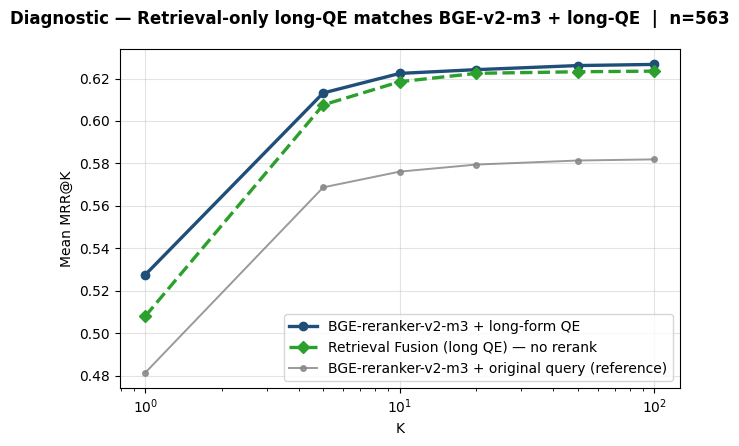

In [137]:
fig_s3, ax_s3 = plt.subplots(figsize=(6.5, 4.5))

# Two lines: CE+long (best CE+QE configuration) vs retrieval fusion (long QE, no rerank)
if "long" in mrr_curves:
    s = QE_STYLE["long"]
    ax_s3.plot(fig2_ks_mrr, mrr_curves["long"], marker="o", markersize=6,
               color=s["color"], linewidth=2.4, label="BGE-reranker-v2-m3 + long-form QE")

if "fusion_long" in mrr_curves:
    ax_s3.plot(fig2_ks_mrr, mrr_curves["fusion_long"], marker="D", markersize=6,
               color="#2ca02c", linewidth=2.4, linestyle="--",
               label="Retrieval Fusion (long QE) — no rerank")

# Default reference (CE+body) for context
if "body" in mrr_curves:
    ax_s3.plot(fig2_ks_mrr, mrr_curves["body"], marker="o", markersize=4,
               color="#888888", linewidth=1.4, alpha=0.85,
               label="BGE-reranker-v2-m3 + original query (reference)")

ax_s3.set_xscale("log")
ax_s3.set_xlabel("K")
ax_s3.set_ylabel("Mean MRR@K")
ax_s3.grid(True, axis="y", alpha=0.35)
ax_s3.grid(True, axis="x", alpha=0.35)
ax_s3.legend(fontsize=10, loc="lower right")
fig_s3.suptitle(
    f"Diagnostic — Retrieval-only long-QE matches BGE-v2-m3 + long-QE  |  n={n_q}",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
fig_s3_path = fig2_out_dir / "diag_retrieval_only_qe_vs_bge_v2_m3.png"
fig_s3.savefig(fig_s3_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_s3_path)
plt.show()